In [10]:
# --- Imports ---
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# --- Path Configuration ---
PROJ_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CSV_PATH  = PROJ_ROOT / "data" / "processed" / "final_bearing_features_processing.csv"

# --- Data Loading ---
df = pd.read_csv(CSV_PATH)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head()


Dataset loaded: 980 rows, 19 columns.


,file_id,filename,b1_rms,b1_kurtosis,b1_skewness,label,peak_freq_hz,spectral_centroid,spectral_energy,top_freq_1_hz,top_amp_1,top_freq_2_hz,top_amp_2,top_freq_3_hz,top_amp_3,top_freq_4_hz,top_amp_4,top_freq_5_hz,top_amp_5
0,0,2004.02.12.10.32.39,0.074179,0.628763,0.083993,Normal,1009.0,4173.309307,0.010795,1009.0,0.042302,51.0,0.011834,237.0,0.005546,4372.0,0.004718,4640.0,0.004434
1,1,2004.02.12.10.42.39,0.075382,0.648291,0.052142,Normal,1009.0,4197.722211,0.011350,1009.0,0.035461,51.0,0.012307,237.0,0.007209,4433.0,0.005447,4675.0,0.004663
2,2,2004.02.12.10.52.39,0.076230,0.513475,0.032808,Normal,1009.0,4149.606739,0.011609,1009.0,0.033781,51.0,0.011630,4479.0,0.006478,474.0,0.006135,4723.0,0.004400
3,3,2004.02.12.11.02.39,0.078724,1.157953,0.041486,Normal,1009.0,4125.136873,0.012383,1009.0,0.034970,51.0,0.011518,4695.0,0.006032,4393.0,0.005510,4264.0,0.004083
4,4,2004.02.12.11.12.39,0.078474,0.603177,0.028224,Normal,1009.0,4141.750190,0.012304,1009.0,0.031891,51.0,0.010675,474.0,0.006390,4479.0,0.006086,3555.0,0.004712


In [11]:
# --- Data Exploration ---

# First few rows
print(df.head())

# Dataset dimensions
print(df.shape)

# Class distribution
print(df['label'].value_counts())

# Missing values per column
print(df.isnull().sum())


   file_id             filename    b1_rms  b1_kurtosis  b1_skewness   label  \
0        0  2004.02.12.10.32.39  0.074179     0.628763     0.083993  Normal   
1        1  2004.02.12.10.42.39  0.075382     0.648291     0.052142  Normal   
2        2  2004.02.12.10.52.39  0.076230     0.513475     0.032808  Normal   
3        3  2004.02.12.11.02.39  0.078724     1.157953     0.041486  Normal   
4        4  2004.02.12.11.12.39  0.078474     0.603177     0.028224  Normal   

   peak_freq_hz  spectral_centroid  spectral_energy  top_freq_1_hz  top_amp_1  \
0        1009.0        4173.309307         0.010795         1009.0   0.042302   
1        1009.0        4197.722211         0.011350         1009.0   0.035461   
2        1009.0        4149.606739         0.011609         1009.0   0.033781   
3        1009.0        4125.136873         0.012383         1009.0   0.034970   
4        1009.0        4141.750190         0.012304         1009.0   0.031891   

   top_freq_2_hz  top_amp_2  top_freq_

In [12]:
# --- Dataset Preparation for Machine Learning ---

from sklearn.preprocessing import LabelEncoder

# --- Feature and Label Separation ---
X = df.drop(columns=['file_id', 'filename', 'label'])
y = df['label']

# --- Label Encoding ---
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# --- Data Splitting (80% train / 20% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# --- Feature Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- Output ---
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Classes found:    {encoder.classes_}")


Training samples: 784
Test samples:     196
Classes found:    ['Failure' 'Normal' 'Wear']


In [13]:
# --- Model Training and Evaluation ---

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Model Initialization ---
rf_model  = RandomForestClassifier(n_estimators=100, random_state=42)
svm_model = SVC(kernel='rbf', random_state=42)
gb_model  = GradientBoostingClassifier(n_estimators=100, random_state=42)

# --- Model Training ---
rf_model.fit(X_train_scaled, y_train)
svm_model.fit(X_train_scaled, y_train)
gb_model.fit(X_train_scaled, y_train)


# --- Evaluation Function ---
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a classifier and print accuracy, precision, recall, and F1-score."""
    y_pred    = model.predict(X_test)
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall    = recall_score(y_test, y_pred, average='weighted')
    f1        = f1_score(y_test, y_pred, average='weighted')

    print()
    print(f"{model_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    return accuracy, precision, recall, f1


# --- Execution Block ---
print('=' * 50)
print('EVALUACIÓN DE MODELOS')
print('=' * 50)

rf_metrics  = evaluate_model(rf_model,  X_test_scaled, y_test, 'Random Forest')
svm_metrics = evaluate_model(svm_model, X_test_scaled, y_test, 'SVM')
gb_metrics  = evaluate_model(gb_model,  X_test_scaled, y_test, 'Gradient Boosting')


EVALUACIÓN DE MODELOS

Random Forest:
  Accuracy:  0.9847
  Precision: 0.9853
  Recall:    0.9847
  F1-Score:  0.9845

SVM:
  Accuracy:  0.9541
  Precision: 0.9580
  Recall:    0.9541
  F1-Score:  0.9552

Gradient Boosting:
  Accuracy:  0.9745
  Precision: 0.9753
  Recall:    0.9745
  F1-Score:  0.9743


In [14]:
# --- Model Comparison, Best Model Selection, and Artifact Saving ---

from pathlib import Path
import joblib

# --- Model Comparison Dictionary ---
models = {
    'Random Forest':      (rf_model,  rf_metrics),
    'SVM':                (svm_model, svm_metrics),
    'Gradient Boosting':  (gb_model,  gb_metrics),
}

# --- Best Model Selection (based on accuracy = index 0 of metrics tuple) ---
best_model_name = max(models.keys(), key=lambda k: models[k][1][0])
best_model, best_metrics = models[best_model_name]

# --- Print Results ---
print(f"\n\U0001f3c6 BEST MODEL: {best_model_name}")
print(f"Accuracy: {best_metrics[0]:.4f}")

# --- Path Configuration ---
PROJ_ROOT  = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODELS_DIR = PROJ_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# --- Save Artifacts ---
# Save the best performing model
joblib.dump(best_model, MODELS_DIR / "predictive_model.pkl")

# Save the scaler — important for scaling future inputs before inference
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")

# Save the label encoder — used to convert numeric predictions back to text labels
joblib.dump(encoder, MODELS_DIR / "label_encoder.pkl")

# --- Final Confirmation ---
print("\u2705 Model saved in models/predictive_model.pkl")



🏆 BEST MODEL: Random Forest
Accuracy: 0.9847
✅ Model saved in models/predictive_model.pkl


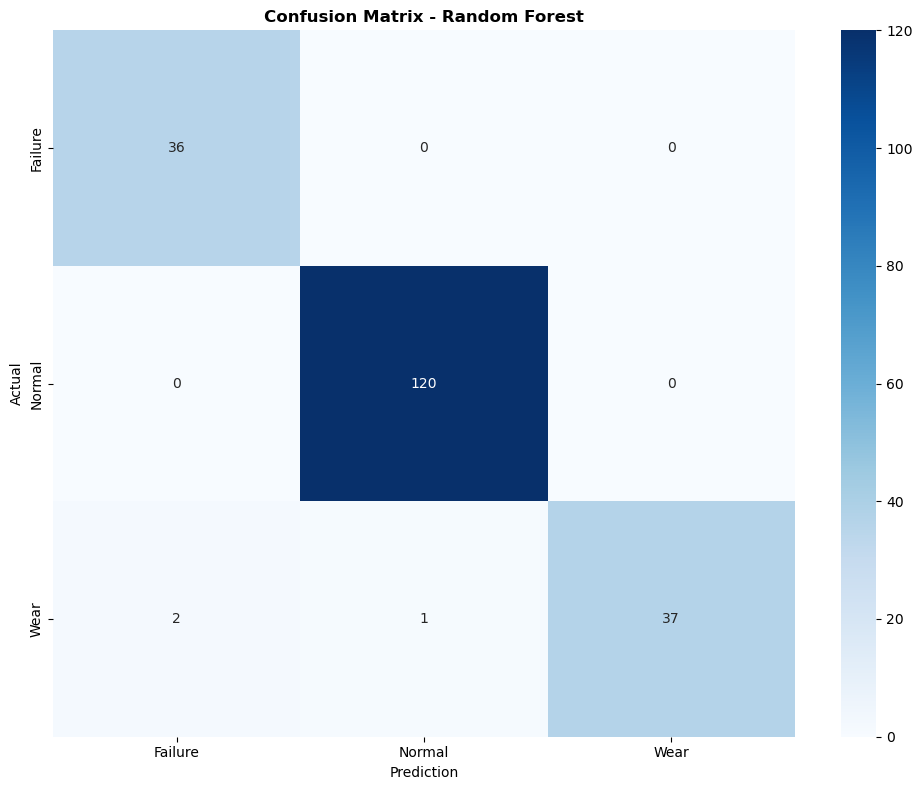


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Failure       0.95      1.00      0.97        36
      Normal       0.99      1.00      1.00       120
        Wear       1.00      0.93      0.96        40

    accuracy                           0.98       196
   macro avg       0.98      0.97      0.98       196
weighted avg       0.99      0.98      0.98       196



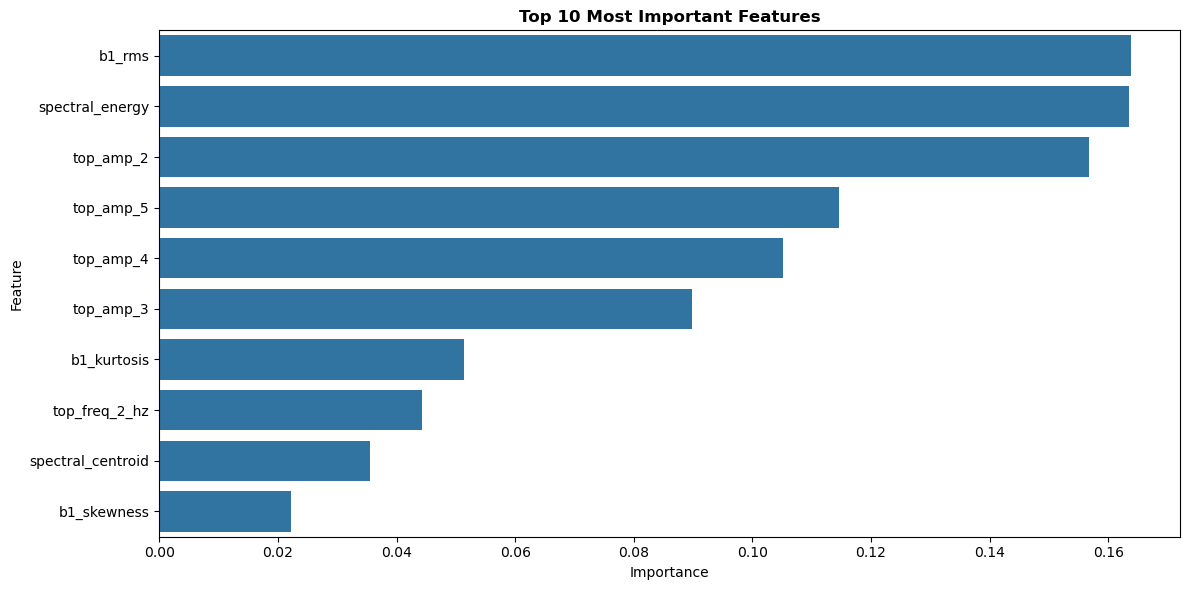

In [15]:
# --- Confusion Matrix, Classification Report, and Feature Importance ---

from sklearn.metrics import confusion_matrix, classification_report

# Use 'le' as an alias consistent with the spec
le = encoder

# --- Directory Setup ---
DEMO_DIR = PROJ_ROOT / "demo"
DEMO_DIR.mkdir(exist_ok=True)

# --- Confusion Matrix ---
y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax
)
ax.set_xlabel('Prediction')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig(DEMO_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Classification Report ---
print('\n' + '=' * 50)
print('DETAILED CLASSIFICATION REPORT')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# --- Feature Importance (Random Forest only) ---
if best_model_name == 'Random Forest':
    importance_df = pd.DataFrame({
        'feature':    X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(
        data=importance_df.head(10),
        x='importance',
        y='feature',
        ax=ax
    )
    ax.set_title('Top 10 Most Important Features', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.savefig(DEMO_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()


In [16]:
# --- 5-Fold Cross-Validation on the Best Model ---

cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("\nCross-Validation (5 folds):")
print(f"Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")



Cross-Validation (5 folds):
Scores: [0.97452229 0.98726115 1.         0.96815287 0.98076923]
Mean Accuracy: 0.9821 (+/- 0.0110)
